# One-Dimensional Linear-Quadratic (LQ) Mean-Field Control Benchmark

References: `files/reference/LQ_framework.tex` (the model, its closed forms and the Riccati optimum), `files/reference/continuous_state_space(2).tex` (the continuous-state theory the compared algorithm implements) and `files/Research_Project.tex`, Sec. "Continuous State Space". Unlike every discrete benchmark in this repo, **the perturbed objective $J^\lambda(\theta)$, its exact policy gradient $\nabla_\theta J^\lambda(\theta)$, and the unperturbed optimal policy are all available in closed form** — so every diagnostic below is measured against an exact oracle rather than against another estimator.

**Model.** State and action spaces are $\mathbb R$. $X_0\sim\mathcal N(\mu_0,\Sigma_0)$; the state law $m_t^\theta=\mathcal N(\mu_t^\theta,\Sigma_t^\theta)$ stays Gaussian and evolves deterministically. The policy is Gaussian feedback $\pi_t^\theta(\cdot\mid x,m)=\mathcal N(\theta_t^1x+\theta_t^2\bar m,\tau^2)$; the transition kernel is $P_t(\cdot\mid x,\alpha,m)=\mathcal N(ax+b\alpha+c\bar m,\sigma^2)$. Running/terminal costs are
$$r_t(x,m,\alpha)=qx^2+r\alpha^2+\kappa\bar m^2, \qquad g(x,m)=q_Tx^2+\kappa_T\bar m^2$$
($\kappa,\kappa_T$ are the reference's own $\gamma,\gamma_T$, renamed here to avoid clashing with this repo's RL discount factor — LQ has no discounting).

**The perturbation** is the continuous-state analogue of the discrete benchmarks' simplex randomization. There, the population law is a probability vector and is perturbed *inside the simplex*, $M_t^{\lambda,\theta}=(1-\lambda)\mu_t^\theta+\lambda q_t$. Here it lives in $\mathcal P_2(\mathbb R)$ and is perturbed *by transport*:
$$M_t^{\lambda,\theta} = (\mathrm{Id}+\lambda f_t)\,\sharp\,\mu_t^\theta, \qquad f_t(x)=\zeta_t x+\beta_t,\quad (\zeta_t,\beta_t)\sim\mathcal N(0,\rho^2)^{\otimes2},$$
drawn afresh along every trajectory. Only the mean of the population law enters this model, so the chart of Assumption "Finite-dimensional law chart" is one-dimensional: the coordinate is $c_t^\theta=\mu_t^\theta$, and $M_t^{\lambda,\theta}=\mu_t^\theta+\lambda\rho\sqrt{(\mu_t^\theta)^2+1}\,\xi_t$ with $\xi_t\sim\mathcal N(0,1)$.

**theta is genuinely time-indexed**: shape $(T,2)$, $\theta_t=(\theta_t^1,\theta_t^2)$ — unlike every other benchmark's stationary/MLP policy, there is no way to evaluate a trained $\theta$ at a horizon other than the one it was trained for.

**Mean-field coupling.** The default `LQConfig` is chosen so the coupling actually matters: $c$ (population feedback in the transition) is comparable to $a$ (self-transition), and $\kappa,\kappa_T$ are comparable to or larger than $q,q_T$. `tests/test_lq.py` checks this numerically: the Riccati-optimal $\theta^\star$ achieves *more than 2x lower cost*, under this environment's own objective, than the optimal $\theta^\star$ of the same problem with the coupling switched off ($c=\kappa=\kappa_T=0$).

**Two model-free algorithms are compared**, both cost-minimizing (note the sign convention: everything here is a *cost*, matching the reference's own notation, unlike the reward-maximization convention used by the rest of this repo — `LQ.MAXIMIZE` is `False`):
- **`simplex`** (`mfc.algorithms.continuous_simplex`): the continuous-state simplex-perturbed MF-REINFORCE estimator. One auxiliary batch estimates the coordinate sensitivities $D_t^\theta=\nabla_\theta\mu_t^\theta$; one main batch forms
  $$\hat g_{B,n,\lambda}(\theta) = \frac1B\sum_{b=1}^B\sum_{t=0}^{T}\Big[\hat D_t\,h_t^{(b)} + \mathbb 1_{\{t<T\}}L_t^{(b)}\Big]\big(G_t^{(b)}-b_t\big),$$
  with $L_t$ the policy score, $h_t=\frac{\xi_t}{\lambda\rho\sqrt{\mu_t^2+1}}+(\xi_t^2-1)\frac{\mu_t}{\mu_t^2+1}$ the population-perturbation score, and $G_t$ the cost-to-go.
- **`reinforce`** (`mfc.algorithms.continuous_reinforce`): exactly the same estimator with $\hat D_t\equiv0$ — the classical-REINFORCE ablation that treats the population law as exogenous (context.md: "Show missing mean-field term by comparison with reinforce"). Run on a common rollout the pair differs by **one term**, which is how the fixed-$\theta$ diagnostics below compare them. In *training* reinforce takes no $\lambda$ at all: the randomization exists only to expose the mean-field sensitivity through a likelihood ratio, so an algorithm that discards that term has no reason to inject it, and is trained on the nominal process instead. Simplex therefore gets one run per $\lambda$ and reinforce a single baseline run, at the same per-step budget.

The closed-form `exact_gradient` is deliberately *not* one of the compared algorithms: it uses the model, which is exactly what the construction exists to avoid. It appears throughout as the **oracle**.

In [1]:
import sys
import time
from pathlib import Path

_notebook_start = time.perf_counter()

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
SRC = ROOT / "src"
for path in (SRC, ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import pandas as pd
import torch

torch.set_default_dtype(torch.float64)
torch.set_default_device("cpu")  # LQ's per-step work is small scalar/(T,B) ops: GPU kernel-launch
                                 # overhead dominates here, same finding as this repo's twostate profiling

from configs.lq import MAIN, MID
from mfc.environments.lq import LQ, LQConfig
from mfc.plotting import diagnostics as viz
from mfc.plotting.style import apply_style, color_for, new_figure, set_style, style_legend
from scripts.train import run_continuous
from scripts.test import (
    continuous_generalization_eval,
    continuous_gradient_diagnostics,
    continuous_mean_field_term,
    continuous_objective_gap,
    continuous_oracle_gradient_estimate,
    continuous_perturbation_coverage,
    continuous_sensitivity_error,
    continuous_state_marginal_stability,
    exact_coordinate_sensitivity,
    load_runs,
)

set_style()

REF_LAM = 0.2  # the reference perturbation scale used wherever a single lambda has to be picked
LABELS = None  # per-component theta labels, set once the horizon is known

# reinforce has no perturbation scale: the randomization exists only to expose
# the mean-field sensitivity through a likelihood ratio, and reinforce drops
# that term -- so it is trained once, on the nominal process, and its runs
# carry lam=None (scripts/train.py's ALGORITHMS_WITH_PERTURBATION_SCALE).
lam_of = lambda alg: REF_LAM if alg == "simplex" else None

## Configuration and budget

This notebook demonstrates the **mid** run tier from `configs/lq.py`: one seed, the reference horizon $T=5$, and the full training length. Run `scripts/train.py --env lq --alg simplex --config main` (and `--alg reinforce`) separately for the full main-tier sweep (5 seeds, horizons $T\in\{3,5,10\}$, used by the horizon-scaling cell below when available).

**Equal budget.** Simplex spends one auxiliary batch plus one main batch per gradient step, $(n_\mathrm{aux}+B)\,T$ simulated transitions; reinforce has no auxiliary batch, so it gets the whole allocation as its main batch. Both therefore cost the same per step (context.md: "For all subsequent environments and tests, we must use equal budget"), and the comparison isolates the estimator, not the sampling effort. The job *counts* differ, though: simplex is trained once per $\lambda$, reinforce once in total, since it has no perturbation scale to sweep.

In [2]:
cfg = MID
env = LQ(device="cpu")  # matches the default device set above and scripts.train.run_continuous's own choice
T = cfg.horizons[0]

print(f"algorithms:   {cfg.algorithms}")
print(f"lambdas:      {cfg.lambdas}")
print(f"T={T}, seeds={cfg.seeds}, lr={cfg.lr}, n_train={cfg.n_train}, baseline={cfg.baseline!r}")
print(f"budget/step:  simplex   n_aux={cfg.n_aux} + B={cfg.B} -> {cfg.transitions_per_step(T)} transitions")
print(f"              reinforce B={cfg.reinforce_B_equal_budget()}          -> {cfg.reinforce_B_equal_budget() * T} transitions (no lambda: trained on the nominal process)")
print(f"model: a={env.config.a}, b={env.config.b}, c={env.config.c}, sigma={env.config.sigma}")
print(f"cost:  q={env.config.q}, r={env.config.r}, q_T={env.config.q_T}, kappa={env.config.kappa}, kappa_T={env.config.kappa_T}")
print(f"tau={env.config.tau}, rho={env.config.rho}, mu0={env.config.mu0}, Sigma0={env.config.Sigma0}")

LABELS = [f"theta_{t}^{i + 1}" for t in range(T) for i in range(2)]

algorithms:   ('simplex', 'reinforce')
lambdas:      (0.05, 0.1, 0.2, 0.4, 0.8)
T=5, seeds=(0,), lr=0.02, n_train=2000, baseline='loo'
budget/step:  simplex   n_aux=200 + B=400 -> 3000 transitions
              reinforce B=600          -> 3000 transitions (no lambda: trained on the nominal process)
model: a=0.9, b=1.0, c=1.0, sigma=0.3
cost:  q=1.0, r=0.1, q_T=5.0, kappa=4.0, kappa_T=10.0
tau=0.2, rho=0.3, mu0=2.0, Sigma0=1.0


## Ground truth: Riccati-optimal policy

The unperturbed ($\lambda=0$) optimal $\theta^\star$ (`LQ.riccati_optimal`, the two decoupled Riccati recursions) and its value $J^0(\theta^\star)$ — exact, closed-form, no training needed. Every plot below compares the learned policies against this.

In [3]:
theta_star = env.riccati_optimal(T)
J_star = env.exact_objective(theta_star, 0.0).item()
grad_at_star = env.exact_gradient(theta_star, 0.0)

print("theta* (self gain, population gain):")
print(theta_star)
print(f"J^0(theta*)      = {J_star:.6f}")
print(f"J^0(theta=0)     = {env.exact_objective(torch.zeros(T, 2), 0.0).item():.4f}   (doing nothing)")
print(f"||grad J^0(theta*)|| = {grad_at_star.norm().item():.2e}  (should be ~0: theta* is a stationary point)")

mu_star, Sigma_star = env.forward_moments(theta_star, 0.0)
print(f"mu_t under theta*: {[round(v, 4) for v in mu_star.tolist()]}")

theta* (self gain, population gain):
tensor([[-0.8233, -1.0418],
        [-0.8233, -1.0418],
        [-0.8233, -1.0418],
        [-0.8237, -1.0415],
        [-0.8824, -1.0051]])
J^0(theta*)      = 23.720854
J^0(theta=0)     = 41485.3650   (doing nothing)
||grad J^0(theta*)|| = 1.42e-15  (should be ~0: theta* is a stationary point)
mu_t under theta*: [2.0, 0.0697, 0.0024, 0.0001, 0.0, 0.0]


## Train (or load cached results)

Loads every saved run under `runs/lq/mid/` for both algorithms; trains first if none exist yet.

In [4]:
runs_dir = ROOT / "runs" / "lq" / cfg.name

runs = []
for alg in cfg.algorithms:
    if not list(runs_dir.glob(f"{alg}_*_seed*.pt")):
        run_continuous("lq", alg, cfg.name)
    runs += load_runs("lq", alg, cfg.name, device="cpu")

by_alg_lambda = {(r["alg"], r["lam"]): r for r in runs}
theta_simplex = by_alg_lambda[("simplex", REF_LAM)]["theta_final"]
theta_reinforce = by_alg_lambda[("reinforce", None)]["theta_final"]

total_train_seconds = sum(r["elapsed_seconds"] for r in runs)
print(f"{len(runs)} runs loaded; total training compute time: {total_train_seconds:.1f}s ({total_train_seconds / 60:.1f} min)")
pd.DataFrame(
    [
        {"alg": r["alg"], "lambda": r["lam"] if r["lam"] is not None else "-", "seed": r["seed"],
         "elapsed_s": round(r["elapsed_seconds"], 1),
         "final J^0": r["validation_J"][-1].item(), "J/J*": r["validation_J"][-1].item() / J_star}
        for r in sorted(runs, key=lambda r: (r["alg"], r["lam"] if r["lam"] is not None else -1.0, r["seed"]))
    ]
).set_index(["alg", "lambda", "seed"])

6 runs loaded; total training compute time: 38.0s (0.6 min)


elapsed_s  final J^0      J/J*
alg       lambda seed                                
reinforce -      0           3.7  25.004792  1.054127
simplex   0.05   0           6.9  24.359598  1.026928
          0.1    0           6.8  24.137169  1.017551
          0.2    0           6.8  24.071779  1.014794
          0.4    0           6.9  24.103509  1.016132
          0.8    0           6.8  24.080177  1.015148

## Evolution of the validation objective

The exact validation objective $J^0(\theta_m)$ (closed-form, not Monte Carlo) every `validate_every` training iterations — one line per $\lambda$ for simplex and a single line for reinforce, which has none — against the Riccati-optimal reference line. Both algorithms are stochastic here, so both curves carry sampling noise; what to look for is where each one *settles* relative to $J^0(\theta^\star)$.

/home/adonis/Internship/MFC_RL/.venv/lib/python3.12/site-packages/torch/utils/_device.py:122: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1879.)
  return func(*args, **kwargs)


Text(0.0, 1.0, 'Validation objective during training (dashed = Riccati optimum)')

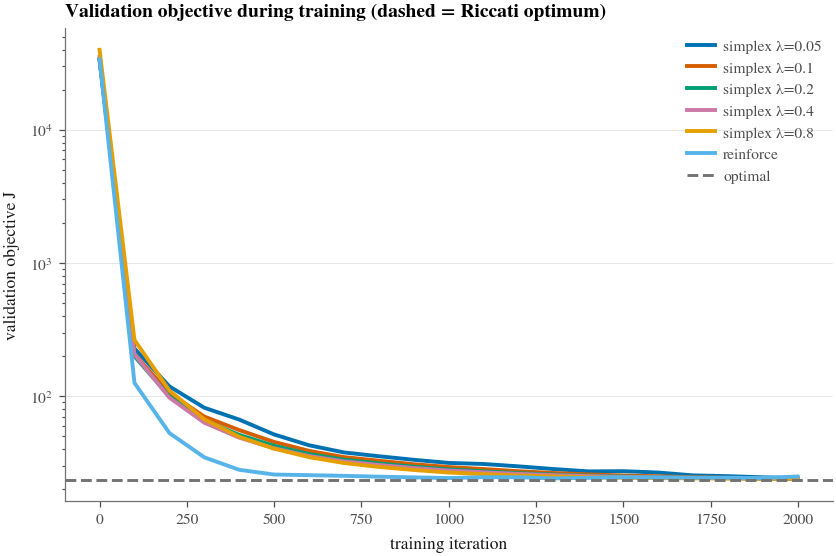

In [5]:
fig, ax = viz.plot_validation_curve(runs, optimal_J=J_star)
ax.set_yscale("log")  # theta_0=0 starts ~600x above the optimum; a linear axis shows only that first drop
ax.set_ylabel("validation cost (log scale)")
ax.set_title("Validation cost by training iteration")

## Learned theta vs Riccati-optimal theta

$\theta_t^1$ (self gain) and $\theta_t^2$ (population gain) across $t$ for each algorithm's $\lambda=0.2$ policy, against $\theta^\star$ (dashed). The population gain $\theta^2$ is the component the missing mean-field term acts on: it is what couples the agent's control to the population it belongs to.

,||theta - theta*||,||theta^1 - theta^1*||,||theta^2 - theta^2*||
alg,,,
simplex,1.127391,0.596477,0.956675
reinforce,1.156219,0.558976,1.012121


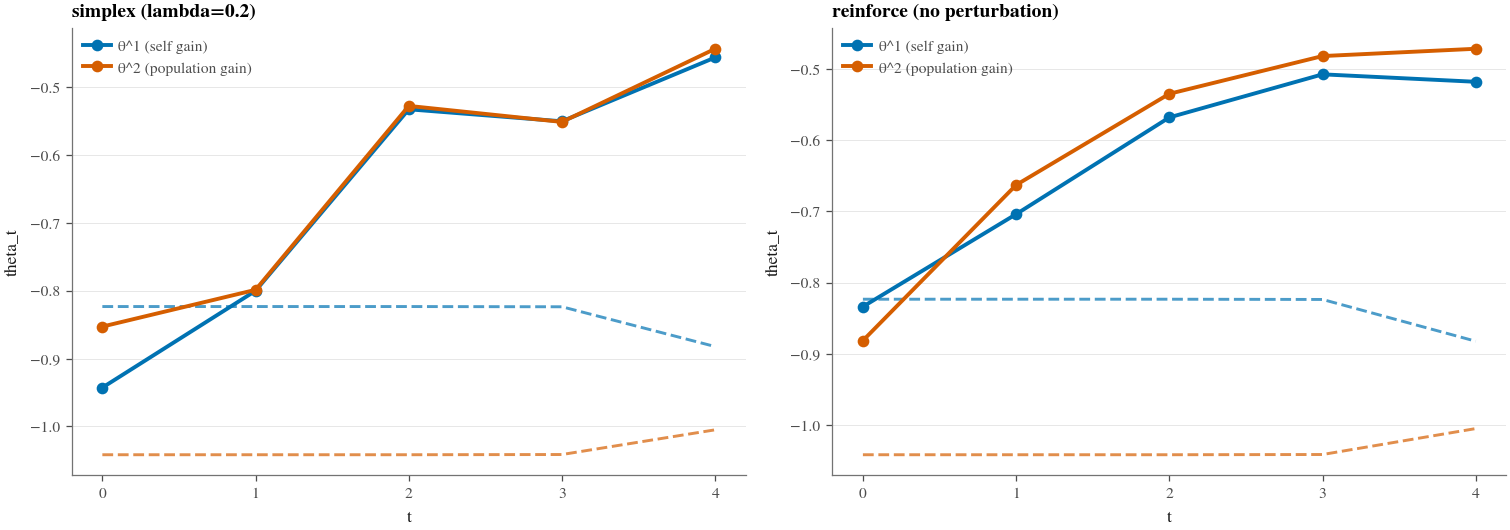

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
viz.plot_lq_theta(theta_simplex, optimal_theta=theta_star, ax=axes[0])
axes[0].set_title(f"Simplex policy parameters (lambda={REF_LAM})")
viz.plot_lq_theta(theta_reinforce, optimal_theta=theta_star, ax=axes[1])
axes[1].set_title("REINFORCE policy parameters (no perturbation)")
fig.tight_layout()

pd.DataFrame(
    [
        {"alg": alg, "||theta - theta*||": (th - theta_star).norm().item(),
         "||theta^1 - theta^1*||": (th[:, 0] - theta_star[:, 0]).norm().item(),
         "||theta^2 - theta^2*||": (th[:, 1] - theta_star[:, 1]).norm().item()}
        for alg, th in (("simplex", theta_simplex), ("reinforce", theta_reinforce))
    ]
).set_index("alg")

## State law over time: learned vs optimal

$\mu_t^\theta\pm\sigma_t^\theta$ (mean $\pm$ 1 std of the Gaussian state law) under each learned policy, against the Riccati-optimal trajectory — the continuous-state counterpart of the discrete notebooks' "state distribution over time".

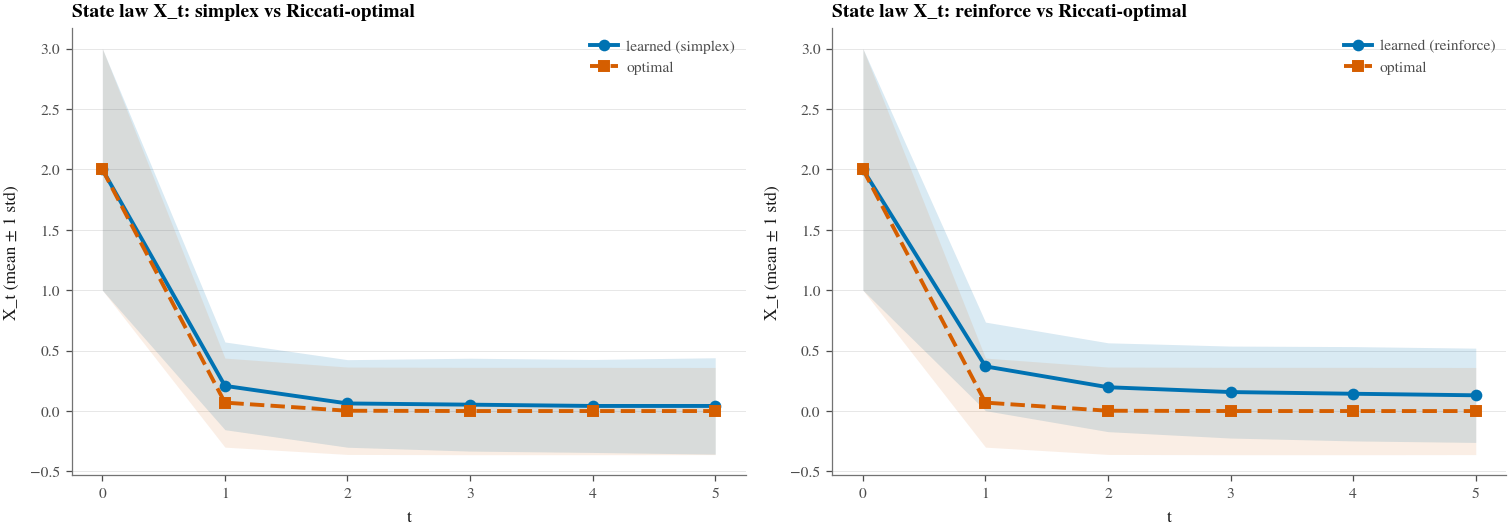

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (alg, th) in zip(axes, (("simplex", theta_simplex), ("reinforce", theta_reinforce))):
    mu_l, Sigma_l = env.forward_moments(th, 0.0)
    viz.plot_gaussian_flow(mu_l, Sigma_l, optimal_mu=mu_star, optimal_Sigma=Sigma_star, label=f"learned ({alg})", ax=ax)
    ax.set_title(f"State distribution: {alg} vs Riccati optimum")
fig.tight_layout()

## $J^\lambda$ vs $J^0$, at the learned and optimal theta

Both sides of this comparison are exact closed-form evaluations (`LQ.exact_objective`), not Monte Carlo estimates — removing that source of noise is LQ's whole purpose. The perturbation only ever *adds* cost here, and the reference's own $O(\lambda^2)$ bias identity ($J^\lambda(\theta)-J^0(\theta)=\lambda^2\rho^2\mathcal B(\theta)$, `LQ.objective_bias`) is checked exactly in `tests/test_lq.py`.

Text(0.0, 1.0, 'Perturbed objective vs lambda, at learned and optimal theta')

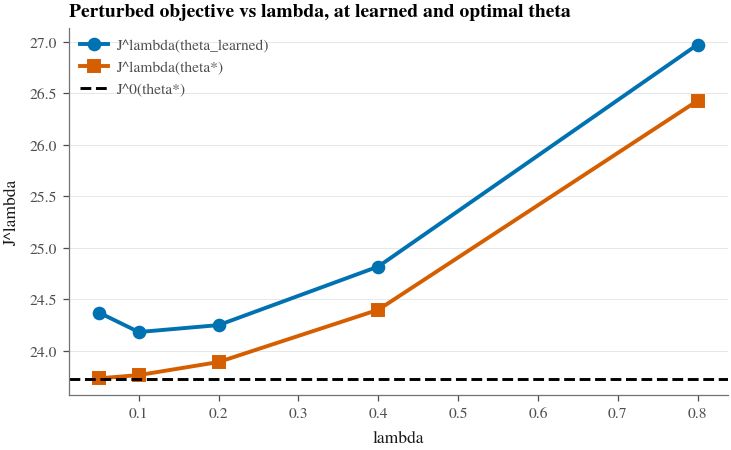

In [8]:
lambdas = list(cfg.lambdas)
J_at_learned = {lam: env.exact_objective(by_alg_lambda[("simplex", lam)]["theta_final"], lam).item() for lam in lambdas}
J_at_optimal = {lam: env.exact_objective(theta_star, lam).item() for lam in lambdas}

fig, ax = new_figure()
ax.plot(lambdas, list(J_at_learned.values()), color=color_for(0), linewidth=2, marker="o", markersize=6, label="J^lambda(theta_learned)")
ax.plot(lambdas, list(J_at_optimal.values()), color=color_for(1), linewidth=2, marker="s", markersize=6, label="J^lambda(theta*)")
ax.axhline(J_star, color="black", linestyle="--", linewidth=1.5, label="J^0(theta*)")
apply_style(ax, xlabel="perturbation scale λ", ylabel="J^lambda")
style_legend(ax)
ax.set_title("Perturbed objective across lambda values")

## Gradient bias, variance and MSE: simplex vs reinforce

The headline benchmark. At a **fixed** $\theta$ (each algorithm's own learned policy would confound the estimator with where it converged, so both are evaluated at the *same* $\theta^\star$), `reps` independent draws of each estimator are compared against the exact $\nabla_\theta J^0(\theta^\star)$, which is exactly zero at the Riccati optimum. Simplex is swept over $\lambda$; reinforce has no $\lambda$, so it appears once, as the estimator it actually trains on ($\lambda=0$, the nominal process). Because both oracles are closed-form, the bias splits **exactly**:

$$\underbrace{\mathbb E[\hat g]-\nabla J^0}_{\text{bias}} = \underbrace{\nabla J^\lambda-\nabla J^0}_{\text{(III) perturbation}} + \underbrace{\mathbb E[\hat g]-\nabla J^\lambda}_{\text{(II) estimation}}.$$

For simplex, (II) is the $O(1/n)$ plug-in error of the shared sensitivity estimate; for reinforce it is the entire missing mean-field term, which does not shrink with any batch size.

In [9]:
reps = 60
grad_diag = {
    "simplex": {
        lam: continuous_gradient_diagnostics(
            env, theta_star, lam=lam, B=cfg.B, n_aux=cfg.n_aux, reps=reps, algorithm="simplex",
            baseline=cfg.baseline, generator=torch.Generator(device="cpu").manual_seed(0),
        )
        for lam in lambdas
    },
    # reinforce takes no lambda: this is the estimator it actually trains on
    "reinforce": {
        0.0: continuous_gradient_diagnostics(
            env, theta_star, lam=0.0, B=cfg.reinforce_B_equal_budget(), reps=reps, algorithm="reinforce",
            baseline=cfg.baseline, generator=torch.Generator(device="cpu").manual_seed(0),
        )
    },
}

rows = []
for alg, per_lam in grad_diag.items():
    for lam, d in per_lam.items():
        rows.append({
            "alg": alg, "λ": lam,
            "||bias||": d["bias"].norm().item(), "bias SE": d["bias_se"].norm().item(),
            "bias/SE": d["bias"].norm().item() / d["bias_se"].norm().item(),
            "(III) perturbation": d["perturbation_bias"].norm().item(),
            "(II) estimation": d["estimation_bias"].norm().item(),
            "||std||": d["std"].norm().item(), "MSE": d["mse"].sum().item(),
        })
pd.DataFrame(rows).set_index(["alg", "λ"])

||bias||    bias SE   bias/SE  (III) perturbation  \
alg       lambda                                                       
simplex   0.05    36.802076  24.360541  1.510725            0.000299   
          0.10     3.837585   2.259428  1.698476            0.001195   
          0.20     0.824525   0.870489  0.947197            0.004781   
          0.40     0.661223   0.897813  0.736481            0.019124   
          0.80     1.004973   1.325728  0.758053            0.076495   
reinforce 0.00     2.210561   0.527188  4.193118            0.000000   

                  (II) estimation     ||std||           MSE  
alg       lambda                                             
simplex   0.05          36.801959  188.695937  36367.113515  
          0.10           3.837079   17.501455    315.922954  
          0.20           0.821914    6.742781     45.387179  
          0.40           0.648402    6.954432     47.995269  
          0.80           0.950852   10.269047    104.705738  
reinforce 0.00           2.210561    4.083580     21.284279

Read the table as: **bias/SE** below ~2 means the estimator is statistically indistinguishable from unbiased at this number of replications; well above 2 means a real bias. Simplex is unbiased at every $\lambda$ (its term (III) is $O(\lambda^2)$ and its term (II) is not resolvable from zero); reinforce is biased, by an amount no batch size would reduce, and all of it is term (II) since it uses no perturbation at all.

Note the trade the two make. Reinforce has the *lower* MSE over most of this grid, because the population-perturbation score it omits is precisely the high-variance part of the estimator (its magnitude is $O(1/\lambda)$). That does not make it the better optimizer: variance averages out across training iterations, while bias does not — it moves the stationary point the recursion converges to, which is why simplex still ends closer to $J^0(\theta^\star)$ in the training table above.

Text(0.0, 1.0, 'Gradient bias, at the optimum (dotted = Monte Carlo SE of the mean)')

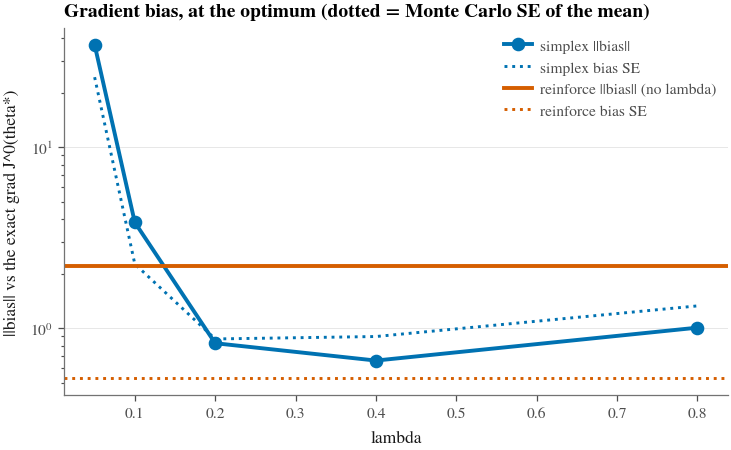

In [10]:
fig, ax = new_figure()
ax.plot(lambdas, [grad_diag["simplex"][lam]["bias"].norm().item() for lam in lambdas],
        color=color_for(0), linewidth=2, marker="o", markersize=6, label="simplex ||bias||")
ax.plot(lambdas, [grad_diag["simplex"][lam]["bias_se"].norm().item() for lam in lambdas],
        color=color_for(0), linewidth=1.5, linestyle=":", label="simplex bias SE")
reinforce_bias = grad_diag["reinforce"][0.0]
ax.axhline(reinforce_bias["bias"].norm().item(), color=color_for(1), linewidth=2, label="reinforce ||bias|| (no lambda)")
ax.axhline(reinforce_bias["bias_se"].norm().item(), color=color_for(1), linewidth=1.5, linestyle=":", label="reinforce bias SE")
ax.set_yscale("log")
apply_style(ax, xlabel="perturbation scale λ", ylabel="gradient-bias norm vs ∇J^0(θ*)")
style_legend(ax)
ax.set_title("Gradient-estimator bias at the optimum")

## The missing mean-field term, isolated

At $\theta^\star$ the true gradient is exactly zero, so any systematic offset an estimator shows there is pure bias. Measuring that bias by independent replication is statistically wasteful, though: the two estimators share their (large) policy-score variance, so most of the replications go into re-measuring noise they have in common.

`continuous_mean_field_term` instead evaluates both on the **same rollouts** and differences them. What survives is exactly the term REINFORCE omits,
$$\sum_{t=0}^T S_t^{\lambda,\theta}(M_t)\,G_t = \sum_{t=0}^T D_t^\theta h_t\, G_t,$$
with the shared policy-score contribution cancelling sample for sample. Since $\mathbb E[\hat g_\text{simplex}]=\nabla J^\lambda$ when the sensitivity flow is exact, this paired quantity *is* REINFORCE's bias, up to the $O(\lambda^2)$ perturbation term — measured to a fraction of the standard error the direct comparison achieves at the same cost.

The measurement is taken at the reference $\lambda$ because the omitted term only *exists* on a perturbed rollout — it is the likelihood-ratio score of the randomization itself. What it predicts, though, is the bias of the $\lambda=0$ REINFORCE that is actually trained: the two differ by the same $O(\lambda^2)$ that separates $\nabla J^\lambda$ from $\nabla J^0$. The last two columns are that unperturbed estimator, measured directly and far more noisily.

In [11]:
mf = continuous_mean_field_term(env, theta_star, lam=REF_LAM, B=cfg.B, reps=200,
                                baseline=cfg.baseline, generator=torch.Generator(device="cpu").manual_seed(0))
direct = grad_diag["reinforce"][0.0]

row = lambda label, text: print(f"{label:<44}: {text}")
row(f"omitted mean-field term (paired, lambda={REF_LAM})", f"{mf['mean'].norm().item():.4f} +- {mf['se'].norm().item():.4f}")
row("reinforce's own bias (direct, lambda=0)",
    f"{direct['bias'].norm().item():.4f} +- {direct['bias_se'].norm().item():.4f}"
    f"  <- same quantity up to O(lambda^2), {direct['bias_se'].norm().item() / mf['se'].norm().item():.0f}x noisier")
row("||grad J^lambda(theta*)||",
    f"{mf['perturbed_gradient'].norm().item():.6f}  (near zero: theta* is the optimum of J^0, "
    "and grad J^lambda - grad J^0 is only O(lambda^2))")
print("-> REINFORCE does not see a near-zero gradient at theta*. What it sees there is essentially this omitted "
      "term, which is exactly what moves the stationary point its recursion converges to away from theta*.")

pd.DataFrame(
    {
        "exact grad J^0(theta*)": grad_at_star.flatten().tolist(),
        "exact grad J^lambda(theta*)": mf["perturbed_gradient"].flatten().tolist(),
        "omitted mean-field term": mf["mean"].flatten().tolist(),
        "term SE": mf["se"].flatten().tolist(),
        "reinforce mean estimate": direct["mean_estimate"].flatten().tolist(),
        "reinforce SE": direct["bias_se"].flatten().tolist(),
    },
    index=LABELS,
)

omitted mean-field term (paired, lambda=0.2): 1.6452 +- 0.1738
reinforce's own bias (direct, lambda=0)     : 2.2106 +- 0.5272  <- same quantity up to O(lambda^2), 3x noisier
||grad J^lambda(theta*)||                   : 0.004781  (near zero: theta* is the optimum of J^0, and grad J^lambda - grad J^0 is only O(lambda^2))
-> REINFORCE does not see a near-zero gradient at theta*. What it sees there is essentially this omitted term, which is exactly what moves the stationary point its recursion converges to away from theta*.


,exact grad J^0(theta*),exact grad J^lambda(theta*),omitted mean-field term,term SE,reinforce mean estimate,reinforce SE
theta_0^1,-8.881784e-16,4.128705e-03,1.163351e+00,1.228512e-01,-1.736662e+00,4.604579e-01
theta_0^2,-1.110223e-15,-1.238928e-03,1.163351e+00,1.228512e-01,-1.367305e+00,2.555625e-01
theta_1^1,1.734723e-17,5.009910e-06,-2.887424e-03,3.885949e-03,-2.446314e-02,1.185298e-02
theta_1^2,5.854692e-18,-1.073727e-03,-2.887424e-03,3.885949e-03,-2.751454e-03,2.091051e-03
theta_2^1,2.081668e-17,6.079030e-09,1.432525e-04,1.315685e-04,8.396515e-03,8.837483e-03
theta_2^2,-6.352747e-21,-1.073519e-03,1.432525e-04,1.315685e-04,-6.141795e-05,6.525484e-05
theta_3^1,1.734723e-17,7.348275e-12,1.000697e-05,4.875092e-06,-1.967972e-02,1.024970e-02
theta_3^2,8.271806e-24,-1.072424e-03,1.000697e-05,4.875092e-06,1.084260e-06,2.340925e-06
theta_4^1,-8.673617e-17,7.757683e-15,-1.957686e-07,1.653394e-07,-8.169180e-04,1.629070e-02
theta_4^2,-4.685203e-26,-9.059603e-04,-1.957686e-07,1.653394e-07,-7.639331e-08,1.020760e-07


## Horizon scaling

Final validation objective and $\|\theta_\text{learned}-\theta^\star\|$ vs horizon $T$, using `runs/lq/main/` if it has been populated (`scripts/train.py --env lq --alg <alg> --config main`); otherwise this cell notes that main-tier data is needed and skips. The estimator's *simulation* cost is linear in $T$ for both algorithms (Remark "Linear per-iteration complexity"), but its statistical constants are not: perturbations of the population law compound forward through the horizon.

In [12]:
main_runs_dir = ROOT / "runs" / "lq" / "main"
probe = lambda alg: f"{alg}_T{MAIN.horizons[0]}" + (f"_lam{REF_LAM}" if lam_of(alg) is not None else "") + "_seed0.pt"
main_runs = [r for alg in cfg.algorithms if (main_runs_dir / probe(alg)).exists()
             for r in load_runs("lq", alg, "main", device="cpu")] if main_runs_dir.exists() else []

if not main_runs:
    print("no runs/lq/main/ data yet -- run scripts/train.py --env lq --alg simplex --config main "
          "(and --alg reinforce) to populate this cell")
else:
    rows = []
    fig, ax = new_figure()
    for i, alg in enumerate(cfg.algorithms):
        J_by_T, err_by_T = {}, {}
        for T_h in MAIN.horizons:
            group = [r for r in main_runs if r["alg"] == alg and r["lam"] == lam_of(alg) and r["T"] == T_h]
            th_star_h = env.riccati_optimal(T_h)
            J_h = sum(r["validation_J"][-1].item() for r in group) / len(group)
            J_by_T[T_h] = J_h / env.exact_objective(th_star_h, 0.0).item()
            err_by_T[T_h] = sum((r["theta_final"] - th_star_h).norm().item() for r in group) / len(group)
            rows.append({"alg": alg, "T": T_h, "J/J*": J_by_T[T_h], "||theta-theta*||": err_by_T[T_h], "n_seeds": len(group)})
        viz.plot_horizon_scaling(J_by_T, ylabel="final J / J*", label=alg, color_index=i, ax=ax)
    ax.set_title("Horizon scaling of final validation cost")
    display(pd.DataFrame(rows).set_index(["alg", "T"]))

no runs/lq/main/ data yet -- run scripts/train.py --env lq --alg simplex --config main (and --alg reinforce) to populate this cell


## Generalization without retraining

Evaluating the $\lambda=0.2$ simplex-learned $\theta$ exactly (no retraining, no Monte Carlo — `LQ.exact_objective` is closed-form) under a different initial law, a stronger perturbation intensity, and model misspecification. LQ's $\theta$ is horizon-specific, so unlike the discrete notebooks there is no "different $T$" scenario here (see `mfc.environments.lq`'s module docstring).

Text(0.0, 1.0, 'J^0.2 under different scenarios (theta fixed, no retraining)')

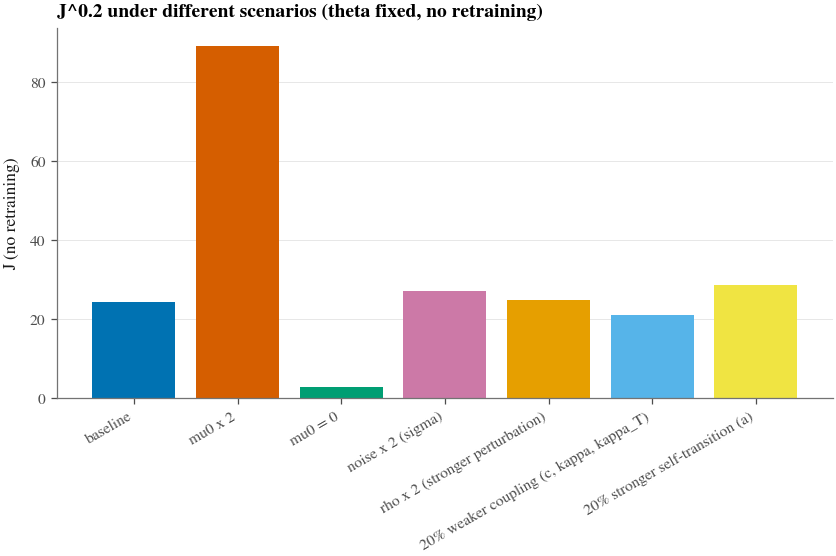

In [13]:
scenarios = [
    {"name": "baseline"},
    {"name": "mu0 x 2", "env": LQ(LQConfig(mu0=env.config.mu0 * 2), device="cpu")},
    {"name": "mu0 = 0", "env": LQ(LQConfig(mu0=0.0), device="cpu")},
    {"name": "noise x 2 (sigma)", "env": LQ(LQConfig(sigma=env.config.sigma * 2), device="cpu")},
    {"name": "rho x 2 (stronger perturbation)", "env": LQ(LQConfig(rho=env.config.rho * 2), device="cpu")},
    {"name": "20% weaker coupling (c, kappa, kappa_T)", "env": LQ(LQConfig(c=env.config.c * 0.8, kappa=env.config.kappa * 0.8, kappa_T=env.config.kappa_T * 0.8), device="cpu")},
    {"name": "20% stronger self-transition (a)", "env": LQ(LQConfig(a=env.config.a * 1.2), device="cpu")},
]
gen_results = continuous_generalization_eval(env, theta_simplex, scenarios, lam=REF_LAM)
fig, ax = viz.plot_generalization(gen_results)
ax.set_title(f"Out-of-distribution objective with fixed learned policy")

## Sample trajectories: learned vs optimal

One sampled $X_t$ trajectory under the $\lambda=0.2$ simplex-learned policy and one under $\theta^\star$, both from $X_0\sim\mathcal N(\mu_0,\Sigma_0)$ and both unperturbed ($\lambda=0$).

Text(0.0, 1.0, 'Sample trajectories (learned solid, optimal dashed)')

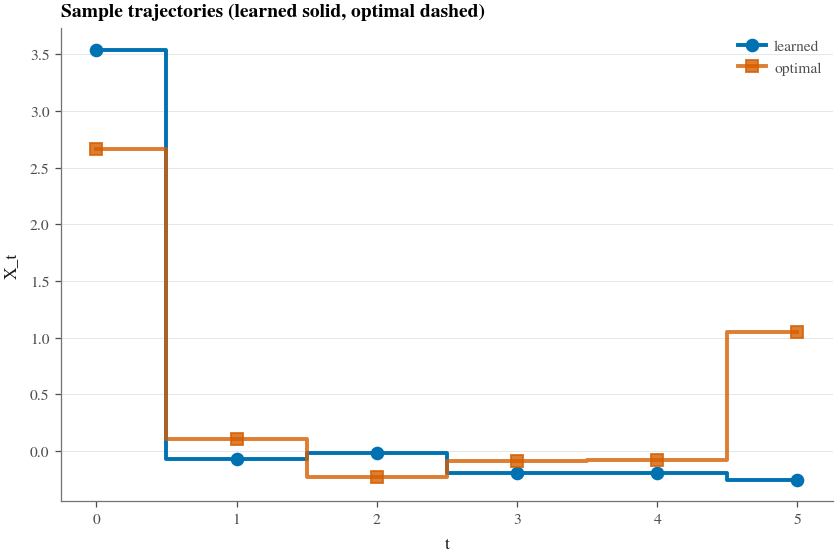

In [14]:
learned_traj = env.rollout(theta_simplex, lam=0.0, B=1, generator=torch.Generator(device="cpu").manual_seed(0))["X"][:, 0]
optimal_traj = env.rollout(theta_star, lam=0.0, B=1, generator=torch.Generator(device="cpu").manual_seed(1))["X"][:, 0]

fig, ax = viz.plot_trajectories(learned_traj, optimal_traj)
ax.set_ylabel("state value X_t")
ax.set_title("Sample state trajectories: learned vs optimal")

## Additional statistical validation (continuous-state theory)

The sections above check the estimators against each other and against training outcomes. The sections below check the theory's own claims from `files/reference/continuous_state_space(2).tex` directly, at a single fixed $\theta$ (the Riccati optimum, so that $\nabla_\theta J^0=0$ exactly) with $\lambda$ or the batch size as the only thing varying. Standard errors are reported throughout, so every point estimate's precision is explicit rather than assumed.

### Convergence of the perturbed objective: $|J^\lambda(\theta)-J^0(\theta)|=O(\lambda^2)$

Proposition "Quantitative perturbation bounds" gives $O(\lambda)$ in general; Remark "Second-order bias" improves it to $O(\lambda^2)$ for a *centered* perturbation, which this one is ($\mathbb E[\lambda Z_t]=0$). Both objectives are closed-form, so the ratio below is exact arithmetic, not a fitted rate — and the Monte Carlo column checks that the simulator the estimators actually run agrees with those closed forms.

In [15]:
gaps = {lam: continuous_objective_gap(env, theta_star, lam=lam, n_samples=200_000,
                                      generator=torch.Generator(device="cpu").manual_seed(0)) for lam in lambdas}
rows = []
for lam in lambdas:
    g = gaps[lam]
    rows.append({
        "λ": lam, "J^0": g["J"].item(), "J^lambda (exact)": g["J_lambda"].item(),
        "J^lambda (MC)": g["J_lambda_mean"].item(), "MC SE": g["J_lambda_se"].item(),
        "|gap|": abs(g["gap"].item()), "|gap|/lambda^2": abs(g["gap"].item()) / lam**2,
    })
pd.DataFrame(rows).set_index("λ")

,J^0,J^lambda (exact),J^lambda (MC),MC SE,|gap|,|gap|/lambda^2
lambda,,,,,,
0.05,23.720854,23.731430,23.724825,0.011196,0.010576,4.230393
0.10,23.720854,23.763158,23.756713,0.011400,0.042304,4.230393
0.20,23.720854,23.890070,23.883929,0.012194,0.169216,4.230393
0.40,23.720854,24.397717,24.392110,0.014997,0.676863,4.230393
0.80,23.720854,26.428306,26.423479,0.023333,2.707452,4.230393


### Gradient-level convergence: $\|\nabla J^\lambda(\theta)-\nabla J^0(\theta)\|=O(\lambda^2)$

The same second-order statement at the gradient level (Remark "Second-order bias", second display). This is term **(III)** of the bias decomposition, and here it needs no estimation at all: both gradients are closed-form, so `exact/lambda^2` being constant *is* the result. The oracle-sensitivity column is the same quantity estimated by Monte Carlo — `continuous_oracle_gradient_estimate` feeds the estimator the *exact* $D_t^\theta$, so its mean is $\nabla J^\lambda$ exactly. At this benchmark's budget the exact gap is orders of magnitude below the estimator's own standard error, so that column should be read as an upper bound consistent with the closed form, not as a measurement of it.

In [16]:
reps_oracle = 40
rows = []
for lam in lambdas:
    generator = torch.Generator(device="cpu").manual_seed(0)
    samples = torch.stack([
        continuous_oracle_gradient_estimate(env, theta_star, lam=lam, B=cfg.B, baseline=cfg.baseline, generator=generator)
        for _ in range(reps_oracle)
    ])
    exact_gap = (env.exact_gradient(theta_star, lam) - grad_at_star).norm().item()
    oracle_gap = (samples.mean(dim=0) - grad_at_star).norm().item()
    rows.append({
        "λ": lam, "||grad J^lambda - grad J^0|| (exact)": exact_gap, "exact/lambda^2": exact_gap / lam**2,
        "oracle-D estimate": oracle_gap, "SE": (samples.std(dim=0) / reps_oracle**0.5).norm().item(),
    })
pd.DataFrame(rows).set_index("λ")

,||grad J^lambda - grad J^0|| (exact),exact/lambda^2,oracle-D estimate,SE
lambda,,,,
0.05,0.000299,0.119523,0.962672,1.899482
0.10,0.001195,0.119523,0.816161,1.249937
0.20,0.004781,0.119523,0.770564,1.014970
0.40,0.019124,0.119523,0.803436,1.004647
0.80,0.076495,0.119523,0.942221,1.345732


### Coordinate-sensitivity estimator: $\hat D_t\to D_t^\theta=\nabla_\theta\mu_t^\theta$

`continuous_simplex.estimate_sensitivity_flow`'s single-batch forward estimator (Algorithm "Single-batch forward estimation of the coordinate sensitivities") against the exact $D_t^\theta$ (autograd through `LQ.forward_moments`). Its error has two parts, and they are controlled by different knobs: the smoothing remainder $R_t^{\eta,\theta}$ shrinks with $\eta$ alone, while the reusable-batch Monte Carlo variance shrinks as $1/n$. $D_0=0$ exactly, since $\mu_0$ does not depend on $\theta$.

In [17]:
reps_sens = 60
rows = []
for eta in lambdas:
    r = continuous_sensitivity_error(env, theta_star, eta=eta, n=cfg.n_aux, reps=reps_sens, generator=torch.Generator(device="cpu").manual_seed(0))
    rows.append({"eta": eta, "n": cfg.n_aux, "||bias||": r["total_bias_norm"].item(), "bias SE": r["bias_se"].sum().item(), "MSE": r["total_mse"].item()})
print(f"bias vs. eta at the training batch size n={cfg.n_aux}:")
display(pd.DataFrame(rows).set_index("eta"))

rows = []
for n in (cfg.n_aux, 4 * cfg.n_aux, 16 * cfg.n_aux):
    r = continuous_sensitivity_error(env, theta_star, eta=REF_LAM, n=n, reps=reps_sens, generator=torch.Generator(device="cpu").manual_seed(0))
    rows.append({"n": n, "eta": REF_LAM, "||bias||": r["total_bias_norm"].item(), "variance": r["variance"].sum().item(), "MSE": r["total_mse"].item()})
print(f"\nvariance vs. n at fixed eta={REF_LAM}:")
display(pd.DataFrame(rows).set_index("n"))

bias vs. eta at the training batch size n=200:


,n,||bias||,bias SE,MSE
eta,,,,
0.05,200,7.381624,10.485507,2658.859873
0.10,200,1.057826,2.204076,79.458112
0.20,200,0.305271,0.793520,8.628117
0.40,200,0.172446,0.411079,2.136913
0.80,200,0.133324,0.289507,1.026693



variance vs. n at fixed eta=0.2:


,eta,||bias||,variance,MSE
n,,,,
200,0.2,0.305271,8.534926,8.628117
800,0.2,0.122533,1.884470,1.899485
3200,0.2,0.079418,0.423600,0.429907


### Mean-squared error vs the perturbation scale

Theorem "Bias and MSE of the gradient estimator" gives, at fixed budget,
$$\mathrm{MSE}(\hat g_{B,n,\lambda}) \lesssim \lambda^{2p} + \frac1{n\lambda^2} + \frac1{B\lambda^2}, \qquad p=2\ \text{here},$$
a U-shape in $\lambda$: perturbation bias dominates at large $\lambda$, estimator variance at small $\lambda$. Corollary "Balanced sampling and perturbation scale" balances the two at $\lambda\asymp m^{-1/(2p+2)}$. The sweep below is the same estimator at the same $\theta^\star$ over a wider $\lambda$ range, at the training budget and at 4x it — the variance branch should fall with the larger budget while the bias branch does not move.

Text(0.0, 1.0, 'Gradient MSE vs lambda: bias branch (right) and variance branch (left)')

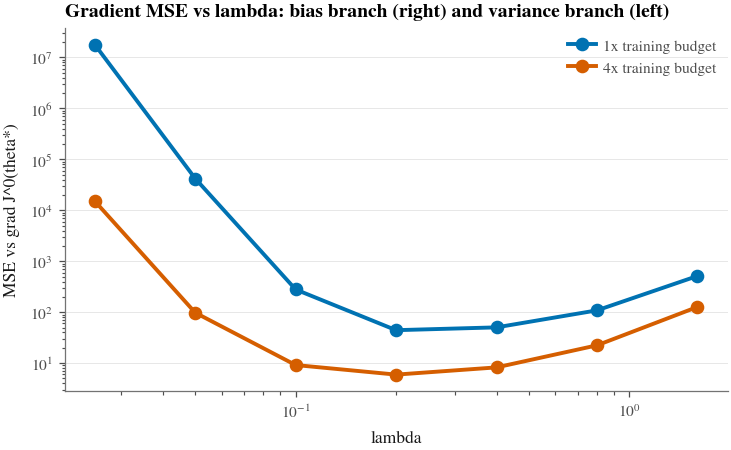

In [18]:
reps_mse = 40
lam_grid = [0.025, 0.05, 0.1, 0.2, 0.4, 0.8, 1.6]
mse_by_budget = {}
for scale in (1, 4):
    mse_by_budget[scale] = {
        lam: continuous_gradient_diagnostics(
            env, theta_star, lam=lam, B=scale * cfg.B, n_aux=scale * cfg.n_aux, reps=reps_mse,
            baseline=cfg.baseline, generator=torch.Generator(device="cpu").manual_seed(0),
        )["mse"].sum().item()
        for lam in lam_grid
    }

fig, ax = new_figure()
for i, (scale, mse) in enumerate(mse_by_budget.items()):
    viz.plot_horizon_scaling(mse, xlabel="perturbation scale λ", ylabel="squared gradient error vs ∇J^0(θ*)",
                             label=f"{scale}x training budget", color_index=i, integer_xaxis=False, ax=ax)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Gradient mean-squared error across perturbation scales")

### Perturbation coverage: $W_2(M_t^\lambda,\mu_t)\le\lambda|Z_t|\sqrt{1+\mu_t^2+\Sigma_t}$

The transport analogue of the discrete benchmarks' almost-sure $d_{TV}(M^\lambda,\mu)\le\lambda$ check. For the affine directions $\varphi(x)=(x,1)$ the reference's constant is $C_\varphi=1$, and since both laws are Gaussian the distance is available in closed form, $W_2^2=\lambda^2(\zeta\mu_t+\beta)^2+\lambda^2\zeta^2\Sigma_t$. `within_bound` checks the bound on **every single draw**, not just on average; `mean W2^2` is checked against its own closed form $\lambda^2\rho^2(\mu_t^2+1+\Sigma_t)$, the $O(\lambda^2)$ of eq. continuous-coordinate-W2-bound.

In [19]:
coverage = {lam: continuous_perturbation_coverage(env, theta_star, lam=lam, n_samples=20_000,
                                                  generator=torch.Generator(device="cpu").manual_seed(0)) for lam in lambdas}
rows = []
for lam, res in coverage.items():
    for r in res:
        rows.append({"λ": lam, "t": r["t"], "mu_t": r["mu"].item(), "mean W2": r["mean_W2"].item(),
                     "max W2": r["max_W2"].item(), "mean W2^2": r["mean_W2_sq"].item(),
                     "predicted W2^2": r["predicted_mean_W2_sq"].item(), "within bound": r["within_bound"]})
df = pd.DataFrame(rows).set_index(["λ", "t"])
print(f"bound holds on every draw, at every (lambda, t): {df['within bound'].all()}")
df

bound holds on every draw, at every (lambda, t): True


mu_t   mean W2    max W2  mean W2^2  predicted W2^2  \
lambda t                                                                
0.05   0  2.000000e+00  0.030378  0.151855   0.001388        0.001350   
       1  6.966876e-02  0.013598  0.075242   0.000258        0.000257   
       2  2.426868e-03  0.013492  0.061703   0.000253        0.000254   
       3  8.453837e-05  0.013556  0.072755   0.000257        0.000254   
       4  2.942561e-06  0.013467  0.056937   0.000254        0.000254   
       5  3.702560e-08  0.013614  0.062647   0.000259        0.000254   
0.10   0  2.000000e+00  0.060756  0.303710   0.005553        0.005400   
       1  6.966876e-02  0.027196  0.150483   0.001034        0.001027   
       2  2.426868e-03  0.026984  0.123407   0.001012        0.001018   
       3  8.453837e-05  0.027111  0.145510   0.001028        0.001018   
       4  2.942561e-06  0.026933  0.113874   0.001015        0.001018   
       5  3.702560e-08  0.027228  0.125293   0.001036        0.001017   
0.20   0  2.000000e+00  0.121512  0.607419   0.022211        0.021600   
       1  6.966876e-02  0.054392  0.300966   0.004134        0.004107   
       2  2.426868e-03  0.053968  0.246814   0.004047        0.004071   
       3  8.453837e-05  0.054223  0.291021   0.004111        0.004071   
       4  2.942561e-06  0.053867  0.227747   0.004058        0.004071   
       5  3.702560e-08  0.054456  0.250586   0.004145        0.004068   
0.40   0  2.000000e+00  0.243023  1.214839   0.088845        0.086400   
       1  6.966876e-02  0.108784  0.601933   0.016536        0.016427   
       2  2.426868e-03  0.107937  0.493628   0.016190        0.016284   
       3  8.453837e-05  0.108445  0.582041   0.016442        0.016283   
       4  2.942561e-06  0.107733  0.455494   0.016233        0.016283   
       5  3.702560e-08  0.108911  0.501173   0.016580        0.016273   
0.80   0  2.000000e+00  0.486047  2.429678   0.355381        0.345600   
       1  6.966876e-02  0.217568  1.203866   0.066145        0.065706   
       2  2.426868e-03  0.215874  0.987255   0.064760        0.065134   
       3  8.453837e-05  0.216891  1.164082   0.065769        0.065132   
       4  2.942561e-06  0.215466  0.910988   0.064932        0.065132   
       5  3.702560e-08  0.217822  1.002346   0.066319        0.065090   

          within bound  
lambda t                
0.05   0          True  
       1          True  
       2          True  
       3          True  
       4          True  
       5          True  
0.10   0          True  
       1          True  
       2          True  
       3          True  
       4          True  
       5          True  
0.20   0          True  
       1          True  
       2          True  
       3          True  
       4          True  
       5          True  
0.40   0          True  
       1          True  
       2          True  
       3          True  
       4          True  
       5          True  
0.80   0          True  
       1          True  
       2          True  
       3          True  
       4          True  
       5          True

### Stability of the perturbed state marginal

The continuous counterpart of the discrete notebooks' $d_{TV}(\nu_t^{\lambda,\theta},\mu_t^\theta)$ lemma. Here the *mean* of the perturbed state marginal is exactly unaffected by $\lambda$ — the perturbation is centered, so `LQ.forward_moments`' mean recursion does not contain $\lambda$ at all — and the entire effect is a variance inflation $\Sigma_t^{\theta,\lambda}-\Sigma_t^{\theta,0}=\lambda^2\rho^2V_t^\theta$ that compounds forward through the horizon. The simulated marginal is shown alongside both exact recursions as a check on the simulator.

,exact mean,simulated mean,nominal variance,exact variance,simulated variance
t=0,2.000000e+00,1.999536,1.000000,1.000000,1.008675
t=1,6.966876e-02,0.070568,0.135876,0.135907,0.134839
t=2,2.426868e-03,0.002317,0.130798,0.130805,0.130502
t=3,8.453837e-05,-0.002132,0.130769,0.130775,0.130990
t=4,2.942561e-06,-0.000730,0.130761,0.130768,0.131052
t=5,3.702560e-08,0.000319,0.130041,0.130041,0.130392


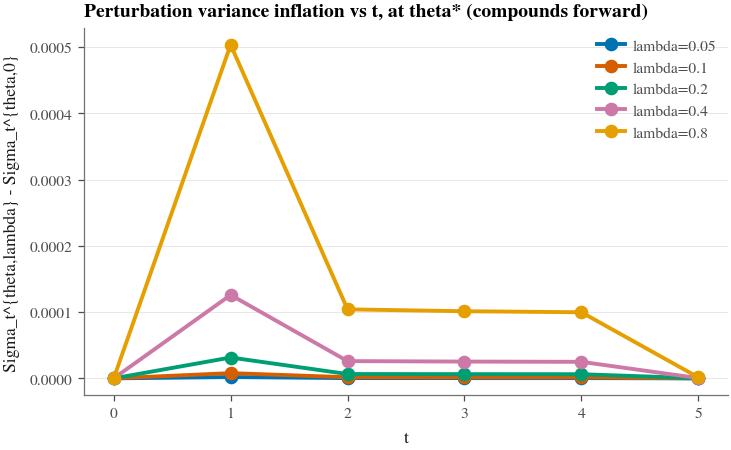

In [20]:
stability = {lam: continuous_state_marginal_stability(env, theta_star, lam=lam, n_samples=100_000,
                                                      generator=torch.Generator(device="cpu").manual_seed(0)) for lam in lambdas}

fig, ax = new_figure()
for i, lam in enumerate(lambdas):
    viz.plot_horizon_scaling({t: v for t, v in enumerate(stability[lam]["variance_inflation"].tolist())},
                             xlabel="t", ylabel="variance inflation: Σ_t^{θ,λ} - Σ_t^{θ,0}", label=f"λ={lam}", color_index=i, ax=ax)
ax.set_title("Perturbation-induced variance inflation over time")

s = stability[REF_LAM]
display(pd.DataFrame({
    "exact mean": s["exact_mean"].tolist(), "simulated mean": s["empirical_mean"].tolist(),
    "nominal variance": s["nominal_variance"].tolist(), "exact variance": s["exact_variance"].tolist(),
    "simulated variance": s["empirical_variance"].tolist(),
}, index=[f"t={t}" for t in range(T + 1)]))

## Summary

Total notebook runtime (including any training performed in this run):

In [21]:
print(f"total notebook runtime: {time.perf_counter() - _notebook_start:.1f}s")

total notebook runtime: 14.8s
